# Sprint 2b — Preparação de Dados para Modelagem Supervisionada

**Objetivo:** Construir features temporais, dividir os dados em treino/validação/teste
com split temporal, e preparar os datasets para treinamento dos classificadores.

**Entrada:** `dados_rotulados` via PostgreSQL (632.985 registros)

**Target:** `regime` (3 classes: 0=Carga Reduzida, 1=Moderado, 2=Alta Carga)

**Saídas:**
- Datasets: treino, validação e teste (parquet)
- Scaler ajustado no treino
- Documentação de features e split

**Pipeline:**
1. Carga e seleção de features base
2. Feature engineering (lags, médias móveis, derivadas)
3. Split temporal (nunca shuffle)
4. Normalização (fit no treino, transform em val/teste)
5. Verificação de balanceamento
6. Salvamento

## 1. Setup

**Objetivo:** Configurar o ambiente de execução — importar bibliotecas (sklearn `RobustScaler`, pandas, numpy), definir caminhos de entrada/saída, conectar ao PostgreSQL e garantir que as tabelas do schema existam.

**Parâmetros:**
- `STAGE = "s2b"` — identificador da etapa no pipeline de dados.
- Diretórios: `data/labeled/` (datasets), `models/` (scaler), `figures/02_sprint2/` (visualizações).

**Justificativa:** A centralização das configurações no início do notebook facilita a manutenção e garante que todas as dependências estejam disponíveis antes do processamento.

In [11]:
import sys, time, warnings, joblib
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado")
DATA_PROC   = PROJECT_ROOT / "data" / "processed"
DATA_LABEL  = PROJECT_ROOT / "data" / "labeled"
FIGURES_DIR = PROJECT_ROOT / "figures" / "02_sprint2"
MODELS_DIR  = PROJECT_ROOT / "models"

for d in [DATA_LABEL, FIGURES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# Acesso ao banco de dados
SCRIPTS_DIR = PROJECT_ROOT / "utils"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))
from db_utils import carregar_dados, salvar_dataframe, salvar_imagem, criar_tabelas

# Criar schema e tabelas (idempotente)
criar_tabelas()

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 19,
    "figure.titlesize": 21,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
STAGE = "s2b"
REGIME_NAMES = {0: "Carga Reduzida", 1: "Moderado", 2: "Alta Carga"}
REGIME_COLORS = ["#66c2a5", "#fc8d62", "#8da0cb"]

t0 = time.time()
print("=" * 60)
print("  S2b — PREPARAÇÃO DE DADOS PARA MODELAGEM")
print("=" * 60)

[db_utils] Schema 'otimizar_moagem_aura' e tabelas criados/verificados com sucesso
  S2b — PREPARAÇÃO DE DADOS PARA MODELAGEM


## 2. Carga e Seleção de Features Base

**Objetivo:** Carregar o dataset rotulado produzido na Sprint 2a (via `carregar_dados("dados_rotulados")`) e selecionar as 27 variáveis de processo como features base para a modelagem supervisionada.

**Parâmetros:**
- Target: `regime` (3 classes — Carga Reduzida, Moderado, Alta Carga).
- Features base: todas as colunas com sufixo `_pipoint` (variáveis de processo da planta).
- Filtro: apenas registros com atribuição válida de regime (`regime` não-nulo).

**Justificativa:** Partir do dataset já rotulado pelo clustering (Sprint 2a) permite treinar classificadores supervisionados. As 27 variáveis de processo constituem a representação bruta do estado operacional do moinho, sobre as quais serão construídas features temporais derivadas na próxima etapa.

In [12]:
import re
from db_utils import carregar_dados

# Carregar dataset rotulado do PostgreSQL (saída do S2a)
df = carregar_dados("dados_rotulados")
df = df.drop(columns=["id"], errors="ignore")
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp").sort_index()

# Target — dropna primeiro, depois converter
df = df[df["regime"].notna()].copy()
df["regime"] = df["regime"].astype(float).astype(int)

# Selecionar features base (variáveis de processo)
cols_processo = [c for c in df.columns if c.endswith("_pipoint")]

# Nomes curtos para legibilidade
def nome_curto(col):
    """Remove sufixo _pipoint e prefixo numérico, mantendo nome único."""
    nome = col.replace("_pipoint", "").strip()
    nome = re.sub(r'^\d{4}_', '', nome)
    nome = re.sub(r'\s*_\s*', ' ', nome).strip()
    return nome

mapa_nomes = {c: nome_curto(c) for c in cols_processo}

print(f"Dataset: {df.shape[0]:,} registros")
print(f"Período: {df.index.min()} a {df.index.max()}")
print(f"Features de processo: {len(cols_processo)}")
print(f"Target: regime (3 classes)")
print(f"\nDistribuição do target:")
for r in range(3):
    n = (df["regime"] == r).sum()
    print(f"  R{r} ({REGIME_NAMES[r]:12s}): {n:>8,} ({100*n/len(df):.1f}%)")


[db_utils] 632985 linhas carregadas de otimizar_moagem_aura.dados_rotulados
Dataset: 632,985 registros
Período: 2024-08-01 00:00:00 a 2026-03-01 00:00:00
Features de processo: 27
Target: regime (3 classes)

Distribuição do target:
  R0 (Carga Reduzida):   90,119 (14.2%)
  R1 (Moderado    ):  288,740 (45.6%)
  R2 (Alta Carga  ):  254,126 (40.1%)


## 3. Feature Engineering

**Features derivadas:**

| Tipo | Descrição | Janela |
|------|-----------|--------|
| Lags | Valores defasados | 1, 5, 15 min |
| Médias móveis | Suavização de tendência | 5, 15, 30 min |
| Desvio padrão móvel | Variabilidade local | 5, 15 min |
| Taxa de variação | Derivada (diferença 1ª ordem) | instantâneo |
| Energia específica | Potência / Alimentação | instantâneo |
| CV alimentação | Variabilidade da alimentação | 5 min |

**Nota:** Features são calculadas sobre as variáveis de processo mais relevantes
(alimentação, potência, mancal, corrente, nível CX, pressão HC) para evitar
explosão dimensional.

In [13]:
# Variáveis-chave para feature engineering (subconjunto das mais relevantes)
COLS_KEY = {
    "alim":    "1025_RETOMADA _ TR02 _ BALANÇA_pipoint",
    "pot":     "1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint",
    "mancal":  "1030_MOAGEM _ MO01MANCALSAÍDA _ PRESSÃO_pipoint",
    "corrente":"1030_MOAGEM _ MO01 _ CORRENTE_pipoint",
    "torque":  "1030_MOAGEM _ MO01 _ TORQUE_pipoint",
    "rpm":     "1030_MOAGEM _ MO01 _ ROTAÇÃO_pipoint",
    "nivel_cx":"1030_MOAGEM _ CX01 _ NÍVEL_pipoint",
    "pressao_hc": "1030_MOAGEM _ HC _ PRESSÃO_pipoint",
}

print("Gerando features derivadas...")
n_antes = len(df.columns)

for nome, col in COLS_KEY.items():
    vals = df[col]
    
    # Lags
    for lag in [1, 5, 15]:
        df[f"LAG_{nome}_{lag}"] = vals.shift(lag)
    
    # Médias móveis
    for win in [5, 15, 30]:
        df[f"MM_{nome}_{win}"] = vals.rolling(win, min_periods=1).mean()
    
    # Desvio padrão móvel
    for win in [5, 15]:
        df[f"STD_{nome}_{win}"] = vals.rolling(win, min_periods=1).std()
    
    # Taxa de variação (derivada)
    df[f"DIFF_{nome}"] = vals.diff()

# Energia específica — usar 0 quando alimentação é baixa (moinho parado/vazio)
alim = df[COLS_KEY["alim"]]
pot = df[COLS_KEY["pot"]]
df["FEAT_energia_especifica"] = np.where(alim > 50, pot / alim, 0)

# CV alimentação (5 min) — usar 0 quando média é zero
mm5 = alim.rolling(5, min_periods=1).mean()
std5 = alim.rolling(5, min_periods=1).std()
df["FEAT_cv_alim_5"] = np.where(mm5 > 0, std5 / mm5, 0)

# Razão torque/potência — usar 0 quando potência é baixa
df["FEAT_razao_torque_pot"] = np.where(pot > 100, df[COLS_KEY["torque"]] / pot, 0)

# Hora do dia (feature cíclica)
hour = df.index.hour
df["FEAT_hora_sin"] = np.sin(2 * np.pi * hour / 24)
df["FEAT_hora_cos"] = np.cos(2 * np.pi * hour / 24)

n_depois = len(df.columns)
n_novas = n_depois - n_antes

# Listar todas as features (excluindo target e metadados)
cols_meta = ["regime", "classe_sag", "dureza_3c", "energia_raw", "energia_ema",
             "cv_alimentacao", "is_stable", "capacidade_max"]
feature_cols = [c for c in df.columns if c not in cols_meta]

print(f"Features geradas: {n_novas}")
print(f"Total de features: {len(feature_cols)}")
print(f"\nTipos de features:")
print(f"  Processo (originais): {len(cols_processo)}")
print(f"  Lags:                 {sum(1 for c in feature_cols if c.startswith('LAG_'))}")
print(f"  Médias móveis:        {sum(1 for c in feature_cols if c.startswith('MM_'))}")
print(f"  Desvio padrão:        {sum(1 for c in feature_cols if c.startswith('STD_'))}")
print(f"  Diferenças:           {sum(1 for c in feature_cols if c.startswith('DIFF_'))}")
print(f"  Derivadas (FEAT_):    {sum(1 for c in feature_cols if c.startswith('FEAT_'))}")

Gerando features derivadas...
Features geradas: 77
Total de features: 105

Tipos de features:
  Processo (originais): 27
  Lags:                 24
  Médias móveis:        24
  Desvio padrão:        16
  Diferenças:           8
  Derivadas (FEAT_):    5


## 4. Limpeza Pré-Split

**Objetivo:** Tratar valores ausentes (NaN) introduzidos pela etapa de feature engineering. Esses NaN surgem no início da série temporal, onde não há histórico suficiente para o cálculo de lags (e.g., os primeiros 15 registros não possuem `LAG_*_15`) e derivadas (`DIFF_*`).

**Estratégia:** Forward-fill seguido de preenchimento com 0 para os NaN restantes (primeira linha da série). As features de razão (`FEAT_energia_especifica`, `FEAT_cv_alim_5`, `FEAT_razao_torque_pot`) já recebem 0 quando a condição não se aplica (moinho parado ou potência baixa), evitando NaN.

**Justificativa:** O forward-fill propaga o último valor válido, preservando a continuidade temporal. O preenchimento com 0 afeta apenas as primeiras linhas da série (sem histórico anterior) e é preferível à remoção, que eliminaria registros válidos desnecessariamente.

In [14]:
n_antes = len(df)

# Forward-fill NaN residuais (primeiras linhas dos lags/diff) e preencher restantes com 0
df[feature_cols] = df[feature_cols].ffill().fillna(0)

# Remover registros sem regime válido
df_model = df[feature_cols + ["regime"]].dropna(subset=["regime"])

n_depois = len(df_model)
print(f"Registros antes:  {n_antes:,}")
print(f"Registros depois: {n_depois:,}")
print(f"Removidos: {n_antes - n_depois:,} ({100*(n_antes-n_depois)/max(n_antes,1):.1f}%)")

Registros antes:  632,985
Registros depois: 632,985
Removidos: 0 (0.0%)


## 5. Split Temporal

**Critério:** Split por data, NUNCA shuffle (respeitar a ordem temporal).

| Conjunto | Período | Proporção |
|----------|---------|----------|
| Treino | ago/2024 – ago/2025 | ~60% |
| Validação | set/2025 – nov/2025 | ~20% |
| Teste | dez/2025 – mar/2026 | ~20% |

**Justificativa:** O split temporal garante que o modelo é avaliado em dados
futuros (nunca vistos), simulando a aplicação real em produção.

In [15]:
# Split temporal 70/15/15 (proporcional por quantidade de registros)
# Justificativa: experimentação demonstrou que mais dados de treino (70% vs 67%)
# melhora consistentemente todos os modelos, especialmente para regimes minoritários.
n_total = len(df_model)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)

# Datas de corte calculadas a partir da proporção
CORTE_TRAIN = df_model.index[n_train]
CORTE_VAL = df_model.index[n_train + n_val]

df_train = df_model[df_model.index < CORTE_TRAIN]
df_val   = df_model[(df_model.index >= CORTE_TRAIN) & (df_model.index < CORTE_VAL)]
df_test  = df_model[df_model.index >= CORTE_VAL]

_fmt = "%d/%m/%Y"
print("Split temporal (70/15/15):")
for _nome, _ds in [("Treino", df_train), ("Validação", df_val), ("Teste", df_test)]:
    _pct = 100 * len(_ds) / len(df_model)
    _ini = _ds.index.min().strftime(_fmt)
    _fim = _ds.index.max().strftime(_fmt)
    print(f"  {_nome:10s} {len(_ds):>8,} ({_pct:.1f}%)  {_ini} – {_fim}")

# Distribuição de classes por conjunto
print("\nDistribuição do target por conjunto:")
for nome, subset in [("Treino", df_train), ("Validação", df_val), ("Teste", df_test)]:
    dist = subset["regime"].value_counts(normalize=True).sort_index()
    print(f"  {nome:10s}: ", end="")
    for r in range(3):
        pct = dist.get(r, 0) * 100
        print(f"R{r}={pct:.1f}% ", end="")
    print()


Split temporal (70/15/15):
  Treino      443,089 (70.0%)  01/08/2024 – 20/09/2025
  Validação    94,947 (15.0%)  20/09/2025 – 12/12/2025
  Teste        94,949 (15.0%)  12/12/2025 – 01/03/2026

Distribuição do target por conjunto:
  Treino    : R0=19.7% R1=63.8% R2=16.4% 
  Validação : R0=2.5% R1=3.8% R2=93.6% 
  Teste     : R0=0.3% R1=2.3% R2=97.4% 


[db_utils] Imagem 'split_temporal' salva para etapa s2b


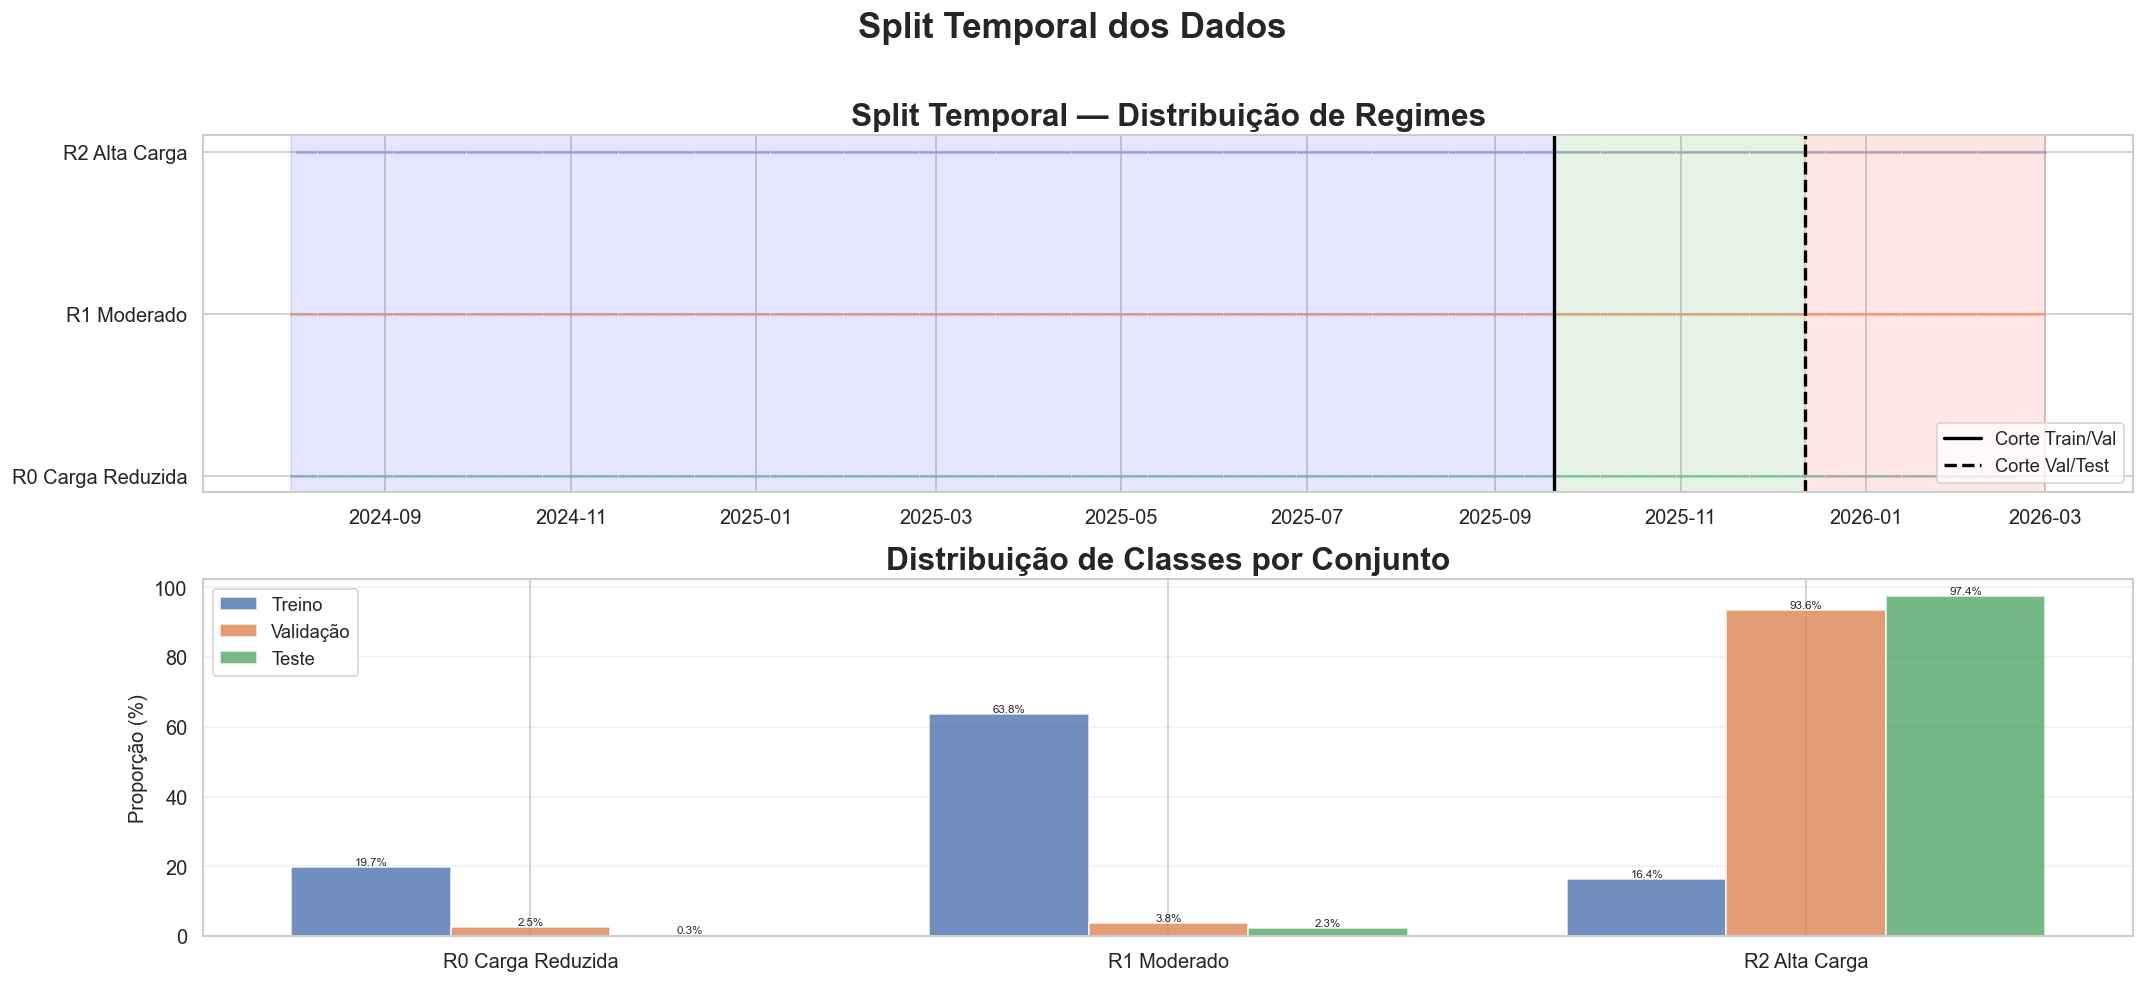

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8))

# 5a. Timeline do split
ax = axes[0]
for r in range(3):
    mask = df_model["regime"] == r
    # Resample diário para não sobrecarregar o gráfico
    daily = df_model[mask].resample("1D").size()
    ax.scatter(daily.index, [r]*len(daily), c=REGIME_COLORS[r], s=1, alpha=0.5)
ax.axvline(CORTE_TRAIN, color="black", linewidth=2, linestyle="-", label="Corte Train/Val")
ax.axvline(CORTE_VAL, color="black", linewidth=2, linestyle="--", label="Corte Val/Test")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels([f"R{r} {REGIME_NAMES[r]}" for r in range(3)])
ax.set_title("Split Temporal — Distribuição de Regimes", fontweight="bold")
ax.legend(fontsize=11)
# Anotar períodos
ax.axvspan(df_model.index.min(), CORTE_TRAIN, alpha=0.1, color="blue", label="Treino")
ax.axvspan(CORTE_TRAIN, CORTE_VAL, alpha=0.1, color="green", label="Validação")
ax.axvspan(CORTE_VAL, df_model.index.max(), alpha=0.1, color="red", label="Teste")

# 5b. Barras: distribuição por conjunto
ax = axes[1]
x = np.arange(3)
width = 0.25
for i, (nome, subset) in enumerate([("Treino", df_train), ("Validação", df_val), ("Teste", df_test)]):
    dist = subset["regime"].value_counts(normalize=True).sort_index()
    vals = [dist.get(r, 0) * 100 for r in range(3)]
    bars = ax.bar(x + i*width, vals, width, label=nome, alpha=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", fontsize=7)
ax.set_xticks(x + width)
ax.set_xticklabels([f"R{r} {REGIME_NAMES[r]}" for r in range(3)])
ax.set_ylabel("Proporção (%)")
ax.set_title("Distribuição de Classes por Conjunto", fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Split Temporal dos Dados", fontsize=21, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S2b_01_split_temporal.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "split_temporal", fig, "S2b_01_split_temporal.png")
plt.show()

## 6. Normalização

**Objetivo:** Padronizar as features com `RobustScaler` (centralização pela mediana, escala pelo IQR), ajustando o scaler exclusivamente nos dados de treino e aplicando a transformação nos conjuntos de validação e teste. O scaler ajustado é persistido em disco para uso na etapa de predição.

**Parâmetros:**
- Scaler: `RobustScaler` (mediana e intervalo interquartil).
- Fit: apenas no conjunto de treino.
- Transform: treino, validação e teste.

**Justificativa:** Ajustar o scaler somente no treino previne vazamento de dados (*data leakage*) — as estatísticas de validação e teste não influenciam a transformação. O `RobustScaler` foi escolhido para manter consistência com o pré-processamento aplicado na Sprint 1 (clustering V2), onde o mesmo scaler foi utilizado. Além disso, o `RobustScaler` é menos sensível a valores extremos residuais que possam ter sobrevivido à etapa de limpeza.

In [17]:
# Separar X e y
X_train = df_train[feature_cols].copy()
y_train = df_train["regime"].copy()
X_val   = df_val[feature_cols].copy()
y_val   = df_val["regime"].copy()
X_test  = df_test[feature_cols].copy()
y_test  = df_test["regime"].copy()

# Ajustar scaler no treino
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=feature_cols
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    index=X_val.index,
    columns=feature_cols
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=feature_cols
)

# Salvar scaler
joblib.dump(scaler, MODELS_DIR / "scaler_classificador.pkl")

print(f"Scaler ajustado no treino ({len(X_train):,} registros)")
print(f"Features: {len(feature_cols)}")
print(f"Scaler salvo: {MODELS_DIR / 'scaler_classificador.pkl'}")
print(f"\nShapes:")
print(f"  X_train: {X_train_scaled.shape}")
print(f"  X_val:   {X_val_scaled.shape}")
print(f"  X_test:  {X_test_scaled.shape}")

Scaler ajustado no treino (443,089 registros)
Features: 105
Scaler salvo: C:\ScriptsDatamindsPIP\4-Projeto aplicado\models\scaler_classificador.pkl

Shapes:
  X_train: (443089, 105)
  X_val:   (94947, 105)
  X_test:  (94949, 105)


## 7. Salvamento dos Datasets

**Objetivo:** Persistir os datasets de treino, validação e teste em formato Parquet (em `data/labeled/`), além de salvar a lista de features e os metadados do split temporal tanto em disco (CSV) quanto no PostgreSQL.

**Parâmetros:**
- Formato: Parquet (features engenheiradas + target `regime`).
- Tabelas PostgreSQL: `s2b_features` (lista de features) e `s2b_split_metadata` (informações do split).
- Datasets **não normalizados** — a normalização é aplicada no notebook de treinamento usando o scaler salvo.

**Justificativa:** Os datasets completos não são salvos nas tabelas principais do banco (estrutura otimizada para as 27 variáveis originais) devido ao grande número de colunas engenheiradas. O formato Parquet oferece compressão eficiente e preserva os tipos de dados. Os metadados no PostgreSQL permitem que o dashboard e outros notebooks consultem a configuração do split sem reprocessamento.

In [18]:
# Salvar datasets (não-escalados — o scaler é aplicado no notebook de treinamento)
# Incluir target junto com features
for nome, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    ds = X.copy()
    ds["regime"] = y
    path = DATA_LABEL / f"dataset_{nome}.parquet"
    ds.to_parquet(path)
    print(f"  {nome:5s}: {path} ({len(ds):,} registros)")

# Salvar lista de features
pd.Series(feature_cols, name="feature").to_csv(DATA_LABEL / "feature_cols.csv", index=False)
print(f"\nLista de features: {DATA_LABEL / 'feature_cols.csv'} ({len(feature_cols)} features)")

# Salvar metadados do split
meta = pd.DataFrame([{
    "corte_train": str(CORTE_TRAIN),
    "corte_val": str(CORTE_VAL),
    "n_train": len(df_train),
    "n_val": len(df_val),
    "n_test": len(df_test),
    "n_features": len(feature_cols),
    "n_classes": 3,
}])
meta.to_csv(DATA_LABEL / "split_metadata.csv", index=False)
print(f"Metadados: {DATA_LABEL / 'split_metadata.csv'}")

# ==============================================================================
# Persistência no PostgreSQL
# ==============================================================================
print("\nSalvando no PostgreSQL...")

# 1. s2b_features — lista de features com ranking
df_features = pd.DataFrame({
    "feature": feature_cols,
    "ranking": range(1, len(feature_cols) + 1),
})
salvar_dataframe(df_features, "s2b_features")

# 2. s2b_split_metadata — informações do split temporal
split_info = []
for nome, ds in [("train", df_train), ("val", df_val), ("test", df_test)]:
    split_info.append({
        "conjunto": nome,
        "n_registros": len(ds),
        "periodo_inicio": ds.index.min(),
        "periodo_fim": ds.index.max(),
        "pct_total": round(100 * len(ds) / (len(df_train) + len(df_val) + len(df_test)), 2),
    })
salvar_dataframe(pd.DataFrame(split_info), "s2b_split_metadata")

# 3. s2b_dataset_train/val/test — datasets completos (rastreabilidade)
for nome, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    ds = X.copy()
    ds["regime"] = y
    salvar_dataframe(ds.reset_index(), f"s2b_dataset_{nome}", modo="replace")

print("\nDados de preparação salvos no PostgreSQL.")

  train: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\labeled\dataset_train.parquet (443,089 registros)
  val  : C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\labeled\dataset_val.parquet (94,947 registros)
  test : C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\labeled\dataset_test.parquet (94,949 registros)

Lista de features: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\labeled\feature_cols.csv (105 features)
Metadados: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\labeled\split_metadata.csv

Salvando no PostgreSQL...
[db_utils] 105 linhas salvas em otimizar_moagem_aura.s2b_features
[db_utils] 3 linhas salvas em otimizar_moagem_aura.s2b_split_metadata
[db_utils] 443,089 linhas salvas em otimizar_moagem_aura.s2b_dataset_train
[db_utils] 94,947 linhas salvas em otimizar_moagem_aura.s2b_dataset_val
[db_utils] 94,949 linhas salvas em otimizar_moagem_aura.s2b_dataset_test

Dados de preparação salvos no PostgreSQL.


## 8. Resumo

**Objetivo:** Consolidar os resultados da preparação de dados — total de registros processados, features engenheiradas (27 originais + 77 derivadas = 104 total), proporções do split temporal, balanceamento de classes em cada conjunto e normalização aplicada.

**Justificativa:** O resumo final permite verificar rapidamente a integridade do pipeline de preparação e identificar eventuais problemas de desbalanceamento ou perda excessiva de dados antes de prosseguir para o treinamento dos classificadores.

In [19]:
elapsed = time.time() - t0
print("\n" + "=" * 60)
print("  RESUMO — PREPARAÇÃO PARA MODELAGEM (S2b)")
print("=" * 60)
print(f"  Tempo total: {elapsed:.0f}s")
print(f"  Features: {len(feature_cols)} ({len(cols_processo)} processo + {n_novas} derivadas)")
print(f"  Target: regime (3 classes)")
print(f"\n  SPLIT TEMPORAL:")
print(f"    Treino:     {len(df_train):>8,} ({100*len(df_train)/len(df_model):.1f}%)")
print(f"    Validação:  {len(df_val):>8,} ({100*len(df_val)/len(df_model):.1f}%)")
print(f"    Teste:      {len(df_test):>8,} ({100*len(df_test)/len(df_model):.1f}%)")
print(f"\n  BALANCEAMENTO (treino):")
for r in range(3):
    n = (y_train == r).sum()
    print(f"    R{r} ({REGIME_NAMES[r]:12s}): {n:>8,} ({100*n/len(y_train):.1f}%)")
print(f"\n  Saídas:")
print(f"    {DATA_LABEL / 'dataset_train.parquet'}")
print(f"    {DATA_LABEL / 'dataset_val.parquet'}")
print(f"    {DATA_LABEL / 'dataset_test.parquet'}")
print(f"    {MODELS_DIR / 'scaler_classificador.pkl'}")
print("=" * 60)


  RESUMO — PREPARAÇÃO PARA MODELAGEM (S2b)
  Tempo total: 85s
  Features: 105 (27 processo + 77 derivadas)
  Target: regime (3 classes)

  SPLIT TEMPORAL:
    Treino:      443,089 (70.0%)
    Validação:    94,947 (15.0%)
    Teste:        94,949 (15.0%)

  BALANCEAMENTO (treino):
    R0 (Carga Reduzida):   87,461 (19.7%)
    R1 (Moderado    ):  282,910 (63.8%)
    R2 (Alta Carga  ):   72,718 (16.4%)

  Saídas:
    C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\labeled\dataset_train.parquet
    C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\labeled\dataset_val.parquet
    C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\labeled\dataset_test.parquet
    C:\ScriptsDatamindsPIP\4-Projeto aplicado\models\scaler_classificador.pkl


In [20]:
# ==============================================================================
# Exportar notebook para HTML (com todos os outputs)
# ==============================================================================
from pathlib import Path
from IPython.display import display, Javascript
import time

# 1. Forçar salvamento do notebook (grava outputs em disco)
display(Javascript("IPython.notebook.save_checkpoint()"))
time.sleep(3)  # Aguardar gravação

# 2. Exportar o .ipynb salvo para HTML
from nbconvert import HTMLExporter
import nbformat

_nb_path = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\notebooks\02_sprint2\b_preparacao_modelagem.ipynb")
_html_dir = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\html")
_html_dir.mkdir(parents=True, exist_ok=True)

with open(_nb_path, encoding="utf-8") as _f:
    _nb_node = nbformat.read(_f, as_version=4)

_exporter = HTMLExporter()
_exporter.exclude_input = True  # Ocultar código, manter outputs
(_html_body, _) = _exporter.from_notebook_node(_nb_node)

_out_path = _html_dir / "b_preparacao_modelagem.html"
_out_path.write_text(_html_body, encoding="utf-8")
print("HTML exportado:", _out_path)

<IPython.core.display.Javascript object>

HTML exportado: C:\ScriptsDatamindsPIP\4-Projeto aplicado\html\b_preparacao_modelagem.html
